# Ch 2 — 導數的悖論 (The Paradox of the Derivative)

> 來自 3Blue1Brown《微積分的本質》第二章

本筆記涵蓋：
1. 「瞬時變化率」為什麼是悖論
2. 用 NumPy 算割線斜率，看 $h \to 0$ 收斂
3. 視覺化割線如何「變」成切線
4. 解析導數 vs 數值導數
5. 把整條導數函數畫出來
6. 練習區
7. 總結與深度學習連結

## Part 1：悖論——「瞬時速度」到底是什麼？

### 故事

一台車在 $t=0$ 從靜止開始往前開，行駛距離函數是

$$s(t) = 4.9\, t^2 \quad\text{(公尺)}$$

問：**車在第 3 秒「那個瞬間」的速度是多少？**

### 為什麼這是悖論？

直覺說「速度 = 距離 / 時間」。但「**那個瞬間**」的時間是 $0$，距離也是 $0$，得到 $\frac{0}{0}$——沒有定義。

> 「在某個瞬間的瞬時變化率」這個說法，**字面上根本不成立**——一個凍結的瞬間裡沒有任何變化。

### 3Blue1Brown 的關鍵洞察

我們真正算的不是「在第 3 秒**那個點**的速度」，而是：

> 在第 3 秒**附近一段微小的時間 $dt$** 的平均速度。

然後讓 $dt$ 越來越小，看這個比值收斂到哪裡：

$$s'(t) = \lim_{dt \to 0} \frac{s(t+dt) - s(t)}{dt}$$

「導數」這個東西，本質上是一個**極限**，而不是某個瞬間的真實量。它的幾何意義就是——**割線變切線**。

## Part 2：環境設定

先匯入需要的套件，並寫一些之後會反覆用到的 helper。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helper ----------
def secant_slope(f, t, dt):
    """割線斜率：f 在 t 與 t+dt 兩點連線的斜率。"""
    return (f(t + dt) - f(t)) / dt


def setup_ax(ax, title=""):
    ax.grid(True, linewidth=0.3)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    if title:
        ax.set_title(title)
    return ax


print("Helpers loaded ✓")

Helpers loaded ✓


## Part 3：割線斜率——當 $dt \to 0$ 會發生什麼？

### 理論

割線（secant line）就是**穿過函數圖上兩個點**的直線。當這兩個點越靠近，割線就越「貼合」原本的曲線。

$$\text{割線斜率} = \frac{s(t+dt) - s(t)}{dt}$$

讓我們在 $t=3$ 處，把 $dt$ 從 $0.5$ 一路縮到 $10^{-9}$，看數字怎麼動。

In [2]:
# === 實驗 1：割線斜率收斂 ===
def s(t):
    return 4.9 * t ** 2

t0 = 3.0
dts = [0.5, 0.1, 0.01, 0.001, 1e-6, 1e-9]

print(f"在 t = {t0} 處，s(t) = 4.9 t² 的割線斜率：")
print(f"{'dt':>12} | {'割線斜率':>16}")
print("-" * 33)
for dt in dts:
    slope = secant_slope(s, t0, dt)
    print(f"{dt:>12.0e} | {slope:>16.10f}")

print()
print(f"解析導數 s'(t) = 9.8 t，在 t={t0} 應該是 {9.8 * t0}")

在 t = 3.0 處，s(t) = 4.9 t² 的割線斜率：
          dt |             割線斜率
---------------------------------
       5e-01 |    31.8500000000
       1e-01 |    29.8900000000
       1e-02 |    29.4490000000
       1e-03 |    29.4049000000
       1e-06 |    29.4000049053
       1e-09 |    29.4000059853

解析導數 s'(t) = 9.8 t，在 t=3.0 應該是 29.400000000000002


觀察：
- $dt$ 越小，割線斜率越靠近 **29.4**
- 解析導數 $s'(t) = 9.8t$，在 $t=3$ 也是 $9.8 \times 3 = 29.4$ ✓
- $dt = 10^{-9}$ 時，浮點誤差開始浮現——這提醒我們**「越小越好」並不總是對**，數值微分有它的精度極限。

## Part 4：視覺化——割線「變」切線

把好幾條不同 $dt$ 的割線疊在同一張圖上，顏色從淺到深，你會看到割線**慢慢轉到**和切線重合。

/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23610 (\N{CJK UNIFIED IDEOGRAPH-5C3A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py

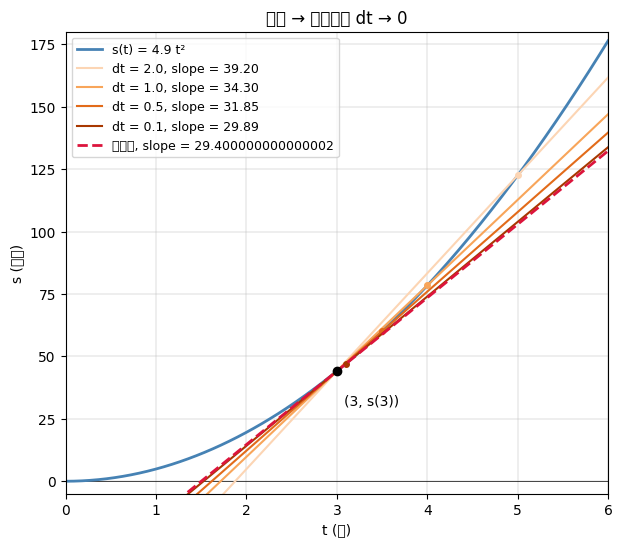

In [3]:
# === 實驗 2：割線變切線的視覺化 ===
t0 = 3.0
dts = [2.0, 1.0, 0.5, 0.1]
colors = ["#fcd5b4", "#f8a55a", "#e26b1a", "#a83800"]

t_grid = np.linspace(0, 6, 200)

fig, ax = plt.subplots(figsize=(7, 6))
setup_ax(ax, title="割線 → 切線：當 dt → 0")

# 畫 s(t) = 4.9 t²
ax.plot(t_grid, s(t_grid), color="steelblue", linewidth=2, label="s(t) = 4.9 t²")

# 標出 t = t0 那個點
ax.plot(t0, s(t0), "o", color="black", markersize=6, zorder=5)
ax.annotate("(3, s(3))", (t0, s(t0)), xytext=(5, -25),
            textcoords="offset points", fontsize=10)

# 畫多條割線
for dt, col in zip(dts, colors):
    slope = secant_slope(s, t0, dt)
    # 割線過 (t0, s(t0))，斜率 = slope
    line_t = np.linspace(0, 6, 50)
    line_s = s(t0) + slope * (line_t - t0)
    ax.plot(line_t, line_s, color=col, linewidth=1.5,
            label=f"dt = {dt}, slope = {slope:.2f}")
    # 標出第二個點 (t0+dt, s(t0+dt))
    ax.plot(t0 + dt, s(t0 + dt), "o", color=col, markersize=4)

# 真正的切線（解析），用粗虛線
true_slope = 9.8 * t0
ax.plot(t_grid, s(t0) + true_slope * (t_grid - t0),
        "--", color="crimson", linewidth=2,
        label=f"真切線, slope = {true_slope}")

ax.set_xlim(0, 6)
ax.set_ylim(-5, 180)
ax.set_xlabel("t (秒)")
ax.set_ylabel("s (公尺)")
ax.legend(fontsize=9, loc="upper left")
plt.show()

你看到的就是「**極限**」這個抽象概念的幾何意義：
- $dt$ 大時，割線斜率明顯偏離真切線
- $dt$ 小時，割線幾乎跟真切線重合
- $dt \to 0$ 是這個過程的**極限狀態**——數學上我們不真的「到達」那個點，但割線斜率有一個**收斂的目標值**，那就是導數。

## Part 5：解析導數 vs 數值導數

對 $f(x) = x^2 + \sin(x)$，解析導數是

$$f'(x) = 2x + \cos(x)$$

我們用三種不同的數值方法逼近它，比比誰最準。

| 方法 | 公式 | 名字 |
|------|------|------|
| 前向差分 | $\frac{f(x+h) - f(x)}{h}$ | forward difference |
| 後向差分 | $\frac{f(x) - f(x-h)}{h}$ | backward difference |
| 中央差分 | $\frac{f(x+h) - f(x-h)}{2h}$ | **central difference**（更準） |

中央差分為什麼更準？它「對稱」地看左右兩邊，把奇次誤差項抵消掉了——這在數值分析裡是很重要的事實。

In [4]:
# === 實驗 3：三種數值微分 PK 解析解 ===
def f(x):
    return x ** 2 + np.sin(x)

def f_analytic_deriv(x):
    return 2 * x + np.cos(x)

x0 = 1.5
h = 1e-4

forward  = (f(x0 + h) - f(x0)) / h
backward = (f(x0) - f(x0 - h)) / h
central  = (f(x0 + h) - f(x0 - h)) / (2 * h)
truth    = f_analytic_deriv(x0)

print(f"在 x = {x0} 處，f(x) = x² + sin(x)：")
print(f"{'方法':<12} | {'估計值':>16} | {'絕對誤差':>16}")
print("-" * 52)
for name, est in [("前向差分", forward), ("後向差分", backward), ("中央差分", central)]:
    err = abs(est - truth)
    print(f"{name:<12} | {est:>16.10f} | {err:>16.2e}")
print(f"{'解析解':<12} | {truth:>16.10f} | {'-':>16}")

在 x = 1.5 處，f(x) = x² + sin(x)：
方法           |              估計值 |             絕對誤差
----------------------------------------------------
前向差分         |     3.0707873268 |         5.01e-05
後向差分         |     3.0706870763 |         5.01e-05
中央差分         |     3.0707372015 |         1.18e-10
解析解          |     3.0707372017 |                -


中央差分的誤差大約比另外兩個**小一兩個數量級**。在 DL 裡做 *gradient check*（驗證自己手寫的反向傳播對不對）時，業界標準就是用中央差分。

## Part 6：把整條導數函數畫出來

導數不只是「在某一點的斜率」，它本身也是一個**函數**——對每個 $x$，你都能算一個 $f'(x)$。

我們對一整條 x 軸取網格，用中央差分算每一點的導數，然後畫出來。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/2861873577.py:27: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/2861873577.py:27: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/2861873577.py:27: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/2861873577.py:27: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/2861873577.py:27: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vz

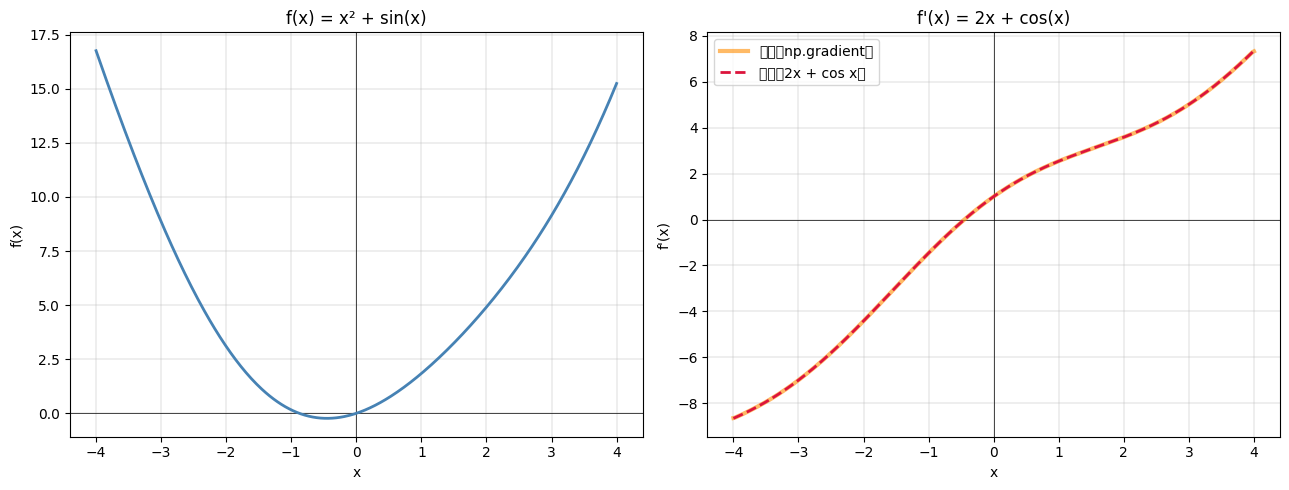

全域最大誤差：2.76e-02


In [5]:
# === 實驗 4：f(x) 與 f'(x) 並排視覺化 ===
xs = np.linspace(-4, 4, 400)
ys = f(xs)

# 用 numpy 的 gradient（內部就是中央差分）
ys_deriv_numerical = np.gradient(ys, xs)
ys_deriv_analytic  = f_analytic_deriv(xs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：原函數
setup_ax(axes[0], title="f(x) = x² + sin(x)")
axes[0].plot(xs, ys, color="steelblue", linewidth=2)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")

# 右：導數函數
setup_ax(axes[1], title="f'(x) = 2x + cos(x)")
axes[1].plot(xs, ys_deriv_numerical, color="darkorange",
             linewidth=3, alpha=0.6, label="數值（np.gradient）")
axes[1].plot(xs, ys_deriv_analytic, "--", color="crimson",
             linewidth=2, label="解析（2x + cos x）")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f'(x)")
axes[1].legend()

plt.tight_layout()
plt.show()

# 數值驗證
max_err = np.max(np.abs(ys_deriv_numerical - ys_deriv_analytic))
print(f"全域最大誤差：{max_err:.2e}")

注意觀察：
- 左圖在某個 $x$ 的**斜率**，等於右圖在同一個 $x$ 的**高度**
- 左圖斜率為 0 的位置（局部極小/極大）= 右圖穿越 0 軸的位置
- 這就是後面**梯度下降**會用的核心事實：**梯度為 0 的地方就是極值點的候選**。

## Part 7：練習區 🏋️

改下面的 `g` 試試其他函數。建議玩玩：

- $g(x) = x^3 - 3x$（兩個極值點）
- $g(x) = e^{-x^2}$（高斯鐘形，導數應該對稱）
- $g(x) = |x|$（在 $x=0$ 不可微——你會看到 `np.gradient` 在 0 附近抖動）
- $g(x) = \sin(5x)/x$（衰減的振盪）

g'(x) ≈ 0 at x ≈ -1.000, g(x) = 2.000
g'(x) ≈ 0 at x ≈ 0.985, g(x) = -1.999


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/4222307192.py:26: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/4222307192.py:26: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/4222307192.py:26: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_51526/4222307192.py:26: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


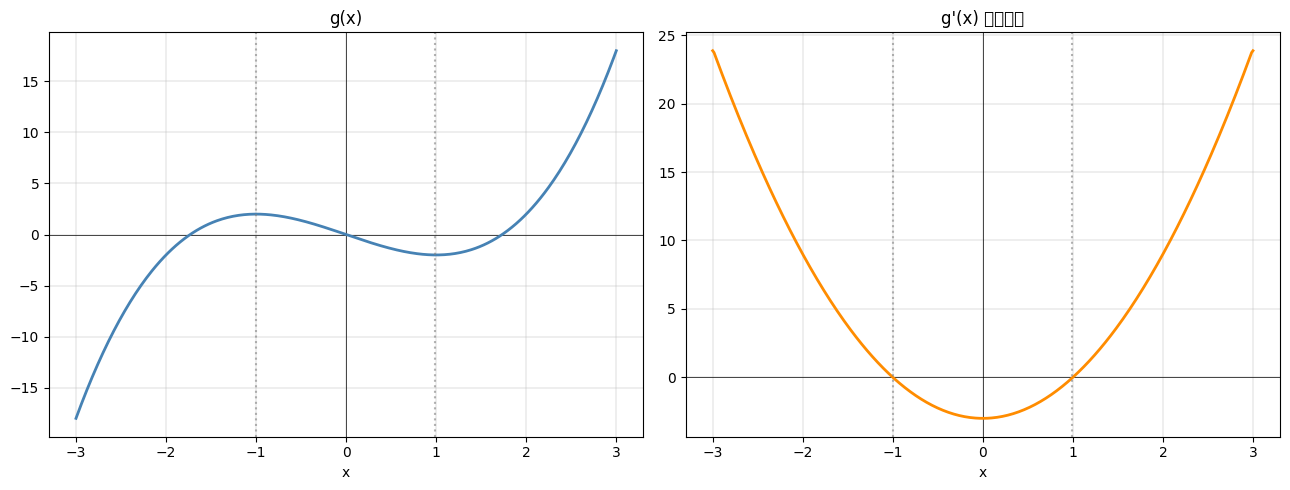

In [6]:
# ===== 練習：自己換一個 g =====
# ✏️ 改這個函數，重新跑！
def g(x):
    return x ** 3 - 3 * x

xs = np.linspace(-3, 3, 400)
ys = g(xs)
ys_deriv = np.gradient(ys, xs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
setup_ax(axes[0], title="g(x)")
axes[0].plot(xs, ys, color="steelblue", linewidth=2)
axes[0].set_xlabel("x")

setup_ax(axes[1], title="g'(x) （數值）")
axes[1].plot(xs, ys_deriv, color="darkorange", linewidth=2)
axes[1].set_xlabel("x")

# 標出 g'(x) ≈ 0 的位置
zero_crossings = np.where(np.diff(np.sign(ys_deriv)))[0]
for idx in zero_crossings:
    axes[0].axvline(xs[idx], color="gray", linestyle=":", alpha=0.6)
    axes[1].axvline(xs[idx], color="gray", linestyle=":", alpha=0.6)
    print(f"g'(x) ≈ 0 at x ≈ {xs[idx]:.3f}, g(x) = {ys[idx]:.3f}")

plt.tight_layout()
plt.show()

## Part 8：總結 & 深度學習連結

### 微積分這一章帶走的事

| 概念 | 一句話 |
|------|------|
| 「瞬時變化率」是悖論 | 真正的定義是「極限」，不是「某個瞬間的真實量」 |
| 導數 = 割線斜率的極限 | $f'(x) = \lim_{h\to0} \frac{f(x+h)-f(x)}{h}$ |
| 導數本身是一個函數 | 對每個 $x$ 都對應一個斜率 |
| 中央差分比前/後向差分準 | 對稱性消去奇次誤差項 |

<br>

### 連到深度學習

| 微積分概念 | DL 對應 |
|---|---|
| 導數 = 函數對輸入的瞬時敏感度 | **梯度** = 損失函數對每個參數的瞬時敏感度 |
| 「往斜率反方向走」 | **梯度下降**：$w \leftarrow w - \eta \, \nabla L(w)$ |
| 數值微分（中央差分） | **gradient check**：驗證自己手寫的反向傳播 |
| $f'(x) = 0$ 是極值點候選 | 訓練收斂時，梯度趨近 0（雖然可能是 saddle point） |
| $h$ 太小會有浮點誤差 | 在 fp16 / bf16 訓練裡這個問題會被放大，所以才有 mixed precision 的講究 |

<br>

### 下一步

- **Ch 3 用幾何求導**：從圖形直接推出 $\frac{d}{dx}x^n = nx^{n-1}$ 等公式
- **Ch 4 鏈式法則**：反向傳播的數學心臟 ❤️
- **Ch 11 泰勒級數**：理解 Adam、牛頓法、二階優化的關鍵